In [2]:
# Cell 1 — Imports and paths
import os, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import date
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

PI_BASE  = '/scratch.global/ocon0444/peat_inventory'
MDL_BASE = '/scratch.global/ocon0444/peat_modeling'
TABLES   = f'{PI_BASE}/peat_inventory_tables'
CATALOG  = f'{MDL_BASE}/MODEL_CATALOG.csv'

RANDOM_STATE = 42
N_FOLDS      = 5
N_TREES      = 500

print('Ready.')

Ready.


In [3]:
# Cell 2 — Load and join all tables
import re

profile = pd.read_csv(f'{TABLES}/Profile.csv')
labdnr  = pd.read_csv(f'{TABLES}/Labdnr.csv')
labulti = pd.read_csv(f'{TABLES}/Labulti.csv')

ID = 'DNR Peat Inventory ID #'

# Join on site + depthnum
df = profile[[ID,'Depthnum','Top Depth (cm)','Bottom Depth (cm)',
               'Degree of Decomposition','Classification']].copy()

df = df.merge(
    labdnr[[ID,'D_Depthnum','D_Bulk Density (g/cc)','D_Ash Content (%)']].rename(
        columns={'D_Depthnum':'Depthnum','D_Bulk Density (g/cc)':'BD_gcc',
                 'D_Ash Content (%)':'Ash_pct'}),
    on=[ID,'Depthnum'], how='left'
)
df = df.merge(
    labulti[[ID,'U_Depthnum','U_Total Carbon (%)']].rename(
        columns={'U_Depthnum':'Depthnum','U_Total Carbon (%)':'SOC_pct'}),
    on=[ID,'Depthnum'], how='left'
)

# Von Post parsing
def parse_vonpost(val):
    if pd.isna(val): return np.nan
    val = str(val).strip()
    m = re.match(r'H(\d+)/H(\d+)', val, re.IGNORECASE)
    if m: return (int(m.group(1)) + int(m.group(2))) / 2
    m = re.match(r'H(\d+)\+', val, re.IGNORECASE)
    if m: return int(m.group(1)) + 0.5
    m = re.search(r'H(\d+)', val, re.IGNORECASE)
    if m: return int(m.group(1))
    return np.nan

df['VonPost'] = df['Degree of Decomposition'].apply(parse_vonpost)

# Depth features
df['top_depth_cm'] = df['Top Depth (cm)'].fillna(0)
df['mid_depth_cm'] = (
    df['Top Depth (cm)'].fillna(0) + df['Bottom Depth (cm)'].fillna(df['Top Depth (cm)'].fillna(0))
) / 2

print(f'Full joined dataframe: {df.shape}')
print(f'SOC_pct non-null: {df["SOC_pct"].notna().sum()}')

Full joined dataframe: (35142, 12)
SOC_pct non-null: 533


In [4]:
# Cell 3 — Build model dataset

PEAT_CLASSES = ['Fibric', 'Hemic', 'Sapric', 'Limnic']

# Filter to rows with SOC measured + all features present
model_df = df[
    df['SOC_pct'].notna() &
    df['VonPost'].notna() &
    df['BD_gcc'].notna() &
    df['Ash_pct'].notna() &
    df['Classification'].isin(PEAT_CLASSES)
].copy().reset_index(drop=True)

print(f'Rows with all features + SOC target: {len(model_df)}')
print(f'Classification breakdown:')
print(model_df['Classification'].value_counts().to_string())
print(f'\nVonPost range: {model_df["VonPost"].min():.1f} - {model_df["VonPost"].max():.1f}')
print(f'SOC range    : {model_df["SOC_pct"].min():.1f} - {model_df["SOC_pct"].max():.1f}%')
print(f'BD range     : {model_df["BD_gcc"].min():.3f} - {model_df["BD_gcc"].max():.3f} g/cc')
print(f'Ash range    : {model_df["Ash_pct"].min():.1f} - {model_df["Ash_pct"].max():.1f}%')
print(f'Depth range  : {model_df["mid_depth_cm"].min():.0f} - {model_df["mid_depth_cm"].max():.0f} cm')

# One-hot encode classification
for cls in PEAT_CLASSES:
    model_df[f'cls_{cls}'] = (model_df['Classification'] == cls).astype(int)

# Feature list
FEATURE_COLS = (
    ['VonPost', 'BD_gcc', 'Ash_pct', 'top_depth_cm', 'mid_depth_cm'] +
    [f'cls_{c}' for c in PEAT_CLASSES]
)

X = model_df[FEATURE_COLS].values
y = model_df['SOC_pct'].values

print(f'\nFeature matrix: {X.shape}')
print(f'Features: {FEATURE_COLS}')

Rows with all features + SOC target: 368
Classification breakdown:
Classification
Hemic     235
Fibric     97
Sapric     36

VonPost range: 1.0 - 9.0
SOC range    : 15.5 - 56.2%
BD range     : 0.020 - 0.370 g/cc
Ash range    : 2.1 - 69.4%
Depth range  : 2 - 692 cm

Feature matrix: (368, 9)
Features: ['VonPost', 'BD_gcc', 'Ash_pct', 'top_depth_cm', 'mid_depth_cm', 'cls_Fibric', 'cls_Hemic', 'cls_Sapric', 'cls_Limnic']


In [5]:
# Cell 4 — 5-fold CV Random Forest

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
fold_results = []
models       = []
y_pred_oof   = np.zeros(len(y))

for fold, (tr_idx, va_idx) in enumerate(kf.split(X)):
    rf = RandomForestRegressor(
        n_estimators=N_TREES, n_jobs=-1, random_state=RANDOM_STATE
    )
    rf.fit(X[tr_idx], y[tr_idx])
    pred = rf.predict(X[va_idx])
    y_pred_oof[va_idx] = pred
    models.append(rf)

    r2   = r2_score(y[va_idx], pred)
    mae  = mean_absolute_error(y[va_idx], pred)
    rmse = np.sqrt(mean_squared_error(y[va_idx], pred))
    fold_results.append({'fold':fold,'r2':r2,'mae':mae,'rmse':rmse})
    print(f'  Fold {fold}  R²={r2:.4f}  MAE={mae:.2f}%  RMSE={rmse:.2f}%')

fold_df  = pd.DataFrame(fold_results)
mean_r2  = fold_df['r2'].mean()
mean_mae = fold_df['mae'].mean()
mean_rmse= fold_df['rmse'].mean()

print(f'\nMean R²  : {mean_r2:.4f} +/- {fold_df["r2"].std():.4f}')
print(f'Mean MAE : {mean_mae:.2f}%')
print(f'Mean RMSE: {mean_rmse:.2f}%')
print(f'\nBaseline (predict mean): R² = 0.0000  MAE = {np.std(y):.2f}%')

  Fold 0  R²=0.1977  MAE=2.00%  RMSE=4.61%
  Fold 1  R²=0.3804  MAE=1.51%  RMSE=2.07%
  Fold 2  R²=0.6541  MAE=1.69%  RMSE=2.20%
  Fold 3  R²=0.5226  MAE=1.78%  RMSE=2.26%
  Fold 4  R²=0.7020  MAE=1.93%  RMSE=3.02%

Mean R²  : 0.4914 +/- 0.2064
Mean MAE : 1.78%
Mean RMSE: 2.83%

Baseline (predict mean): R² = 0.0000  MAE = 4.24%


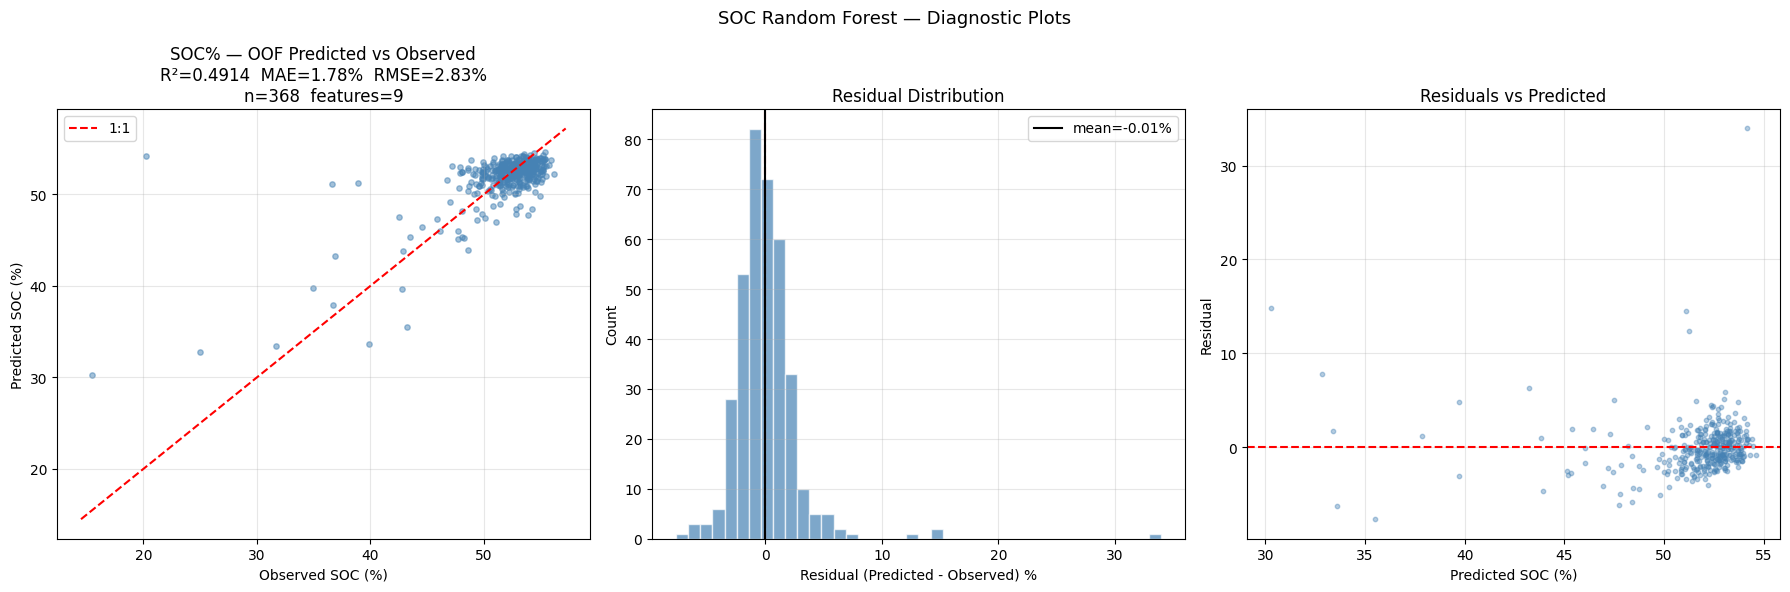

Saved: soc_rf_diagnostics.png


In [6]:
# Cell 5 — Predicted vs observed + residuals

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Scatter
axes[0].scatter(y, y_pred_oof, alpha=0.5, s=15, color='steelblue')
lim = [y.min()-1, y.max()+1]
axes[0].plot(lim, lim, 'r--', lw=1.5, label='1:1')
axes[0].set_xlabel('Observed SOC (%)')
axes[0].set_ylabel('Predicted SOC (%)')
axes[0].set_title(
    f'SOC% — OOF Predicted vs Observed\n'
    f'R²={mean_r2:.4f}  MAE={mean_mae:.2f}%  RMSE={mean_rmse:.2f}%\n'
    f'n={len(y)}  features={len(FEATURE_COLS)}'
)
axes[0].legend(); axes[0].grid(alpha=0.3)

# Residuals
residuals = y_pred_oof - y
axes[1].hist(residuals, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].axvline(0, color='red', lw=1.5, linestyle='--')
axes[1].axvline(residuals.mean(), color='black', lw=1.5,
                label=f'mean={residuals.mean():.2f}%')
axes[1].set_xlabel('Residual (Predicted - Observed) %')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')
axes[1].legend(); axes[1].grid(alpha=0.3)

# Residuals vs predicted
axes[2].scatter(y_pred_oof, residuals, alpha=0.4, s=10, color='steelblue')
axes[2].axhline(0, color='red', lw=1.5, linestyle='--')
axes[2].set_xlabel('Predicted SOC (%)')
axes[2].set_ylabel('Residual')
axes[2].set_title('Residuals vs Predicted')
axes[2].grid(alpha=0.3)

plt.suptitle('SOC Random Forest — Diagnostic Plots', fontsize=13)
plt.tight_layout()
plt.savefig(f'{PI_BASE}/soc_rf_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: soc_rf_diagnostics.png')

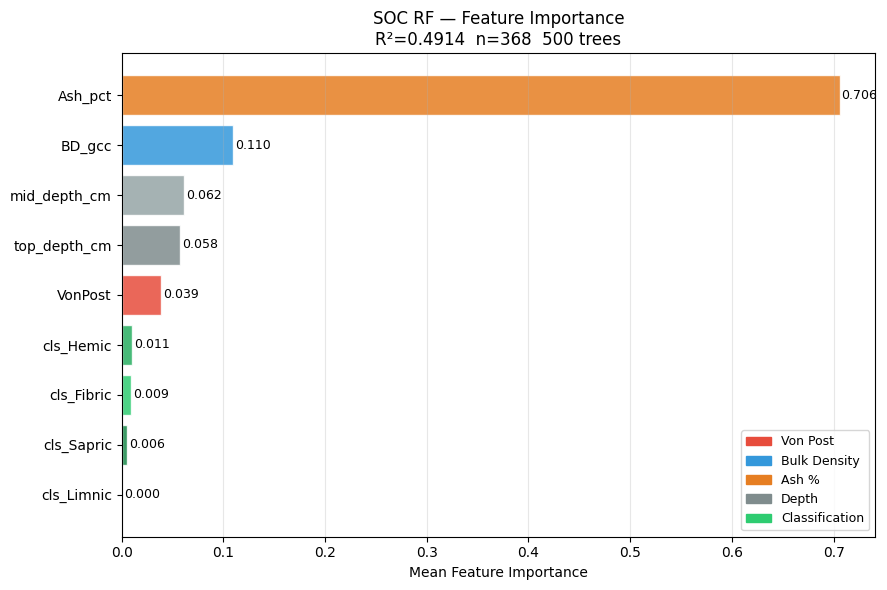

     feature  importance
     Ash_pct    0.705879
      BD_gcc    0.109912
mid_depth_cm    0.061739
top_depth_cm    0.057884
     VonPost    0.038782
   cls_Hemic    0.010648
  cls_Fibric    0.009454
  cls_Sapric    0.005704
  cls_Limnic    0.000000


In [7]:
# Cell 6 — Feature importance

imp = np.mean([m.feature_importances_ for m in models], axis=0)
imp_df = pd.DataFrame({'feature': FEATURE_COLS, 'importance': imp})\
           .sort_values('importance', ascending=False)

feat_colors = {
    'VonPost':       '#e74c3c',
    'BD_gcc':        '#3498db',
    'Ash_pct':       '#e67e22',
    'top_depth_cm':  '#7f8c8d',
    'mid_depth_cm':  '#95a5a6',
    'cls_Fibric':    '#2ecc71',
    'cls_Hemic':     '#27ae60',
    'cls_Sapric':    '#1a8a4a',
    'cls_Limnic':    '#0d6b3a',
}
colors = [feat_colors.get(f, '#7f8c8d') for f in imp_df['feature']]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1],
        color=colors[::-1], alpha=0.85, edgecolor='white')
for i, (feat, val) in enumerate(zip(imp_df['feature'][::-1], imp_df['importance'][::-1])):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('Mean Feature Importance')
ax.set_title(
    f'SOC RF — Feature Importance\n'
    f'R²={mean_r2:.4f}  n={len(y)}  {N_TREES} trees'
)
ax.grid(alpha=0.3, axis='x')

legend_patches = [
    mpatches.Patch(color='#e74c3c', label='Von Post'),
    mpatches.Patch(color='#3498db', label='Bulk Density'),
    mpatches.Patch(color='#e67e22', label='Ash %'),
    mpatches.Patch(color='#7f8c8d', label='Depth'),
    mpatches.Patch(color='#2ecc71', label='Classification'),
]
ax.legend(handles=legend_patches, fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig(f'{PI_BASE}/soc_rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(imp_df.to_string(index=False))

In [8]:
# Cell 7 — Performance by classification group

print(f"{'Class':<10} {'n':>5} {'R²':>8} {'MAE':>8} {'RMSE':>8}")
print('-' * 45)
for cls in PEAT_CLASSES:
    idx = model_df['Classification'] == cls
    if idx.sum() < 5:
        print(f'{cls:<10} {idx.sum():>5}  (too few for metrics)')
        continue
    r2_c   = r2_score(y[idx], y_pred_oof[idx])
    mae_c  = mean_absolute_error(y[idx], y_pred_oof[idx])
    rmse_c = np.sqrt(mean_squared_error(y[idx], y_pred_oof[idx]))
    print(f'{cls:<10} {idx.sum():>5} {r2_c:>8.4f} {mae_c:>8.2f}% {rmse_c:>8.2f}%')

print()
print('Partial dependence — mean predicted SOC by Von Post:')
vp_groups = model_df.groupby(model_df['VonPost'].round().astype(int)).agg(
    n=('SOC_pct','count'),
    obs_mean=('SOC_pct','mean'),
    pred_mean=pd.NamedAgg(column='SOC_pct', aggfunc=lambda x: y_pred_oof[x.index].mean())
).round(2)
print(vp_groups.to_string())

Class          n       R²      MAE     RMSE
---------------------------------------------
Fibric        97   0.0681     1.68%     2.16%
Hemic        235   0.5351     1.77%     3.17%
Sapric        36   0.4719     2.13%     3.59%
Limnic         0  (too few for metrics)

Partial dependence — mean predicted SOC by Von Post:
          n  obs_mean  pred_mean
VonPost                         
1         4     53.20      52.39
2        18     52.62      52.21
3        75     52.33      52.04
4        98     52.26      52.14
5        99     51.53      51.58
6        38     50.60      51.22
7        22     50.55      50.56
8        10     50.19      50.95
9         4     46.30      46.77


In [9]:
# Cell 8 — Save model and update MODEL_CATALOG

import os
EXP_ID   = 'exp_soc_pi'
EXP_NAME = 'SOC % RF - peat inventory - VonPost+Class+Depth+BD+Ash'
NOTES    = (f'Non-spatial RF. n={len(y)} horizon-level peat inventory rows. '
            f'Features: VonPost, BD, Ash, top_depth, mid_depth, cls one-hots. '
            f'{N_TREES} trees, {N_FOLDS}-fold CV.')

model_dir = f'{MDL_BASE}/03_models/{EXP_ID}'
os.makedirs(model_dir, exist_ok=True)
res_dir   = f'{MDL_BASE}/05_results/{EXP_ID}'
os.makedirs(res_dir, exist_ok=True)

# Save fold models
for i, m in enumerate(models):
    pickle.dump(m, open(f'{model_dir}/model_fold_{i}.pkl','wb'))

fold_df.to_csv(f'{model_dir}/cv_results.csv', index=False)
imp_df.to_csv(f'{res_dir}/feature_importance.csv', index=False)

json.dump({
    'exp_id':        EXP_ID,
    'features':      FEATURE_COLS,
    'n_features':    len(FEATURE_COLS),
    'target':        'SOC_pct',
    'n_samples':     len(y),
    'mean_r2':       round(mean_r2, 4),
    'mean_mae':      round(mean_mae, 2),
    'mean_rmse':     round(mean_rmse, 2),
    'n_trees':       N_TREES,
    'spatial':       False,
    'dataset':       'peat_inventory horizon level',
}, open(f'{model_dir}/feature_list.json','w'), indent=2)

# Update catalog
catalog = pd.read_csv(CATALOG)
catalog = catalog[catalog['exp_id'] != EXP_ID]
catalog = pd.concat([catalog, pd.DataFrame([{
    'exp_id':             EXP_ID,
    'exp_name':           EXP_NAME,
    'status':             'active',
    'task':               'soc_regression_nonspatial',
    'dataset':            'peat_inventory horizons',
    'n_samples':          len(y),
    'n_features':         len(FEATURE_COLS),
    'n_trees':            N_TREES,
    'peat_maps_excluded': False,
    'nwi_included':       False,
    'nwi_classes':        'none',
    'depth_bins':         '',
    'output_type':        'SOC_pct',
    'output_values':      '0-100%',
    'mean_acc':           '',
    'mean_f1':            '',
    'mean_auc':           '',
    'mean_r2':            round(mean_r2, 4),
    'mean_rmse':          round(mean_rmse, 2),
    'date':               str(date.today()),
    'notes':              NOTES,
    'notebook':           'soc_rf_model.ipynb',
    'model_dir':          f'03_models/{EXP_ID}',
    'categoricals':       'one-hot classification',
    'mean_avg_prec':      '',
}])], ignore_index=True)
catalog.to_csv(CATALOG, index=False)

print(f'Models saved to: {model_dir}')
print(f'Catalog updated.')
print(f'\nFinal summary:')
print(f'  exp_id    : {EXP_ID}')
print(f'  n_samples : {len(y)}')
print(f'  n_features: {len(FEATURE_COLS)}')
print(f'  mean R²   : {mean_r2:.4f}')
print(f'  mean MAE  : {mean_mae:.2f}%')
print(f'  mean RMSE : {mean_rmse:.2f}%')

Models saved to: /scratch.global/ocon0444/peat_modeling/03_models/exp_soc_pi
Catalog updated.

Final summary:
  exp_id    : exp_soc_pi
  n_samples : 368
  n_features: 9
  mean R²   : 0.4914
  mean MAE  : 1.78%
  mean RMSE : 2.83%


In [10]:
# Add to notebook — check how many unique sites per fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for fold, (tr_idx, va_idx) in enumerate(kf.split(X)):
    n_sites = model_df.iloc[va_idx][ID].nunique()
    print(f'Fold {fold}: {len(va_idx)} rows, {n_sites} unique sites')

Fold 0: 74 rows, 58 unique sites
Fold 1: 74 rows, 54 unique sites
Fold 2: 74 rows, 58 unique sites
Fold 3: 73 rows, 58 unique sites
Fold 4: 73 rows, 58 unique sites
